# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Viet Huynh

**Date:**  11 September 2026

In [ ]:
# Your Phase 1 solution to the problem goes here.
#PHOTOS FOR QUESTION 1 UPLOADED TO GITHUB

In [1]:
!git clone https://github.com/viet-huynh-1/A02-eda-and-visualization.git

Cloning into 'A02-eda-and-visualization'...
remote: Enumerating objects: 10, done.
remote: Counting objects: 100% (4/4), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 10 (delta 0), reused 0 (delta 0), pack-reused 6 (from 1)
Receiving objects: 100% (10/10), 1.19 MiB | 5.43 MiB/s, done.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df1 = pd.read_csv('/content/A02-eda-and-visualization/data/ForeignGifts_edu.csv')
df1.head()

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


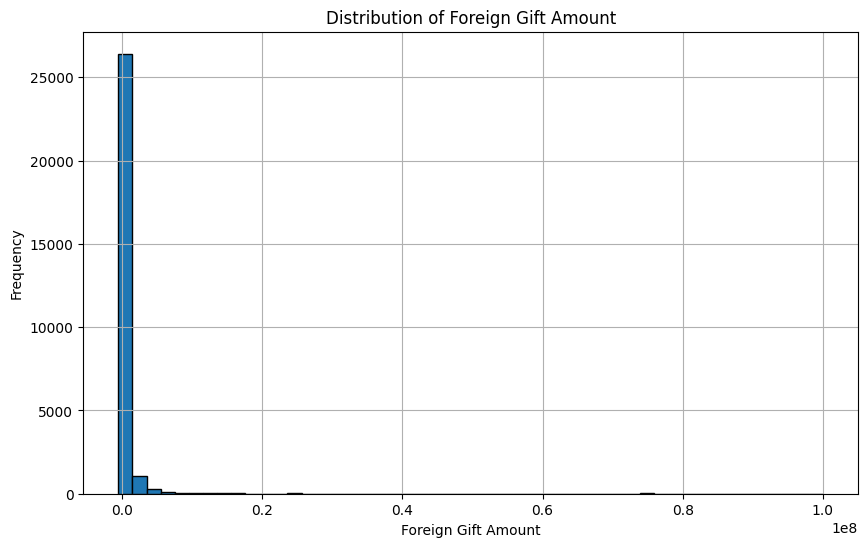

In [11]:
plt.figure(figsize=(10, 6))
plt.hist(df1['Foreign Gift Amount'], bins=50, edgecolor='k')
plt.title('Distribution of Foreign Gift Amount')
plt.xlabel('Foreign Gift Amount')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

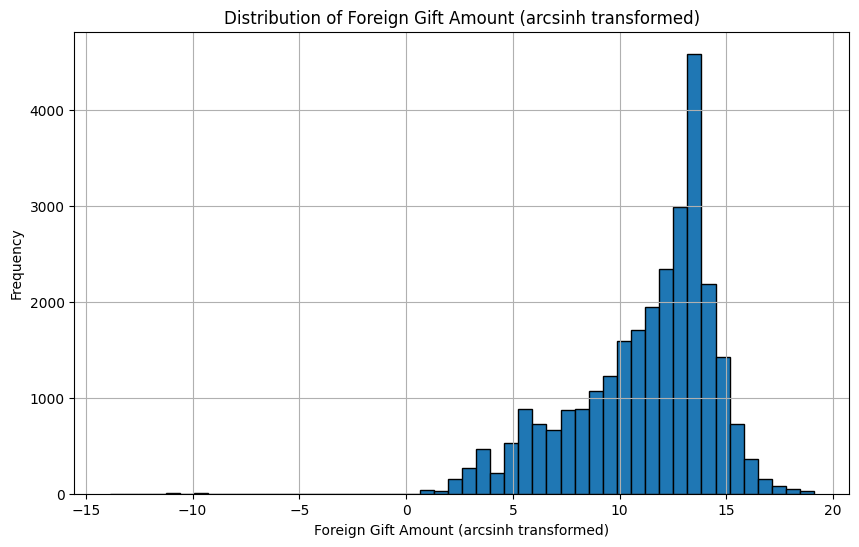

In [12]:
plt.figure(figsize=(10, 6))
#arcsinh transformation to handle both positive and negative values while compressing the scale
plt.hist(np.arcsinh(df1['Foreign Gift Amount']), bins=50, edgecolor='k')
plt.title('Distribution of Foreign Gift Amount (arcsinh transformed)')
plt.xlabel('Foreign Gift Amount (arcsinh transformed)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [9]:
pd.options.display.float_format = '{:.2f}'.format #i got this thanks to stack overflow, it makes the gift amount displayed in standard number form
description = df1['Foreign Gift Amount'].describe()
display(description)
pd.options.display.float_format = None

,Foreign Gift Amount
count,28221.00
mean,588232.72
std,3222011.43
min,-537770.00
25%,5700.00
50%,94615.00
75%,376142.00
max,99999999.00


The relatively low median of around 94k, alongside the maximum value of 100M indicates that the distribution of foreign gift amounts is highly right-skewed, meaning most gifts are relatively small, but there are a few extremely large gifts! The clustering of the data points in the original, unadjusted histogram certainly indicates that most gifts hover around that median, while exceptionally large gifts represent a tiny fraction of the total donations. For some reason there are negative values, which might indicate some kind of expenditure (which probably shouldn't be in a dataset of gifts) or maybe some kind of refund, rebate or something like that.

,count
Gift Type,
Contract,17274
Monetary Gift,10936
Real Estate,11


/tmp/ipykernel_824/1851050624.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gift_type_counts.index, y=gift_type_counts.values, palette='viridis')


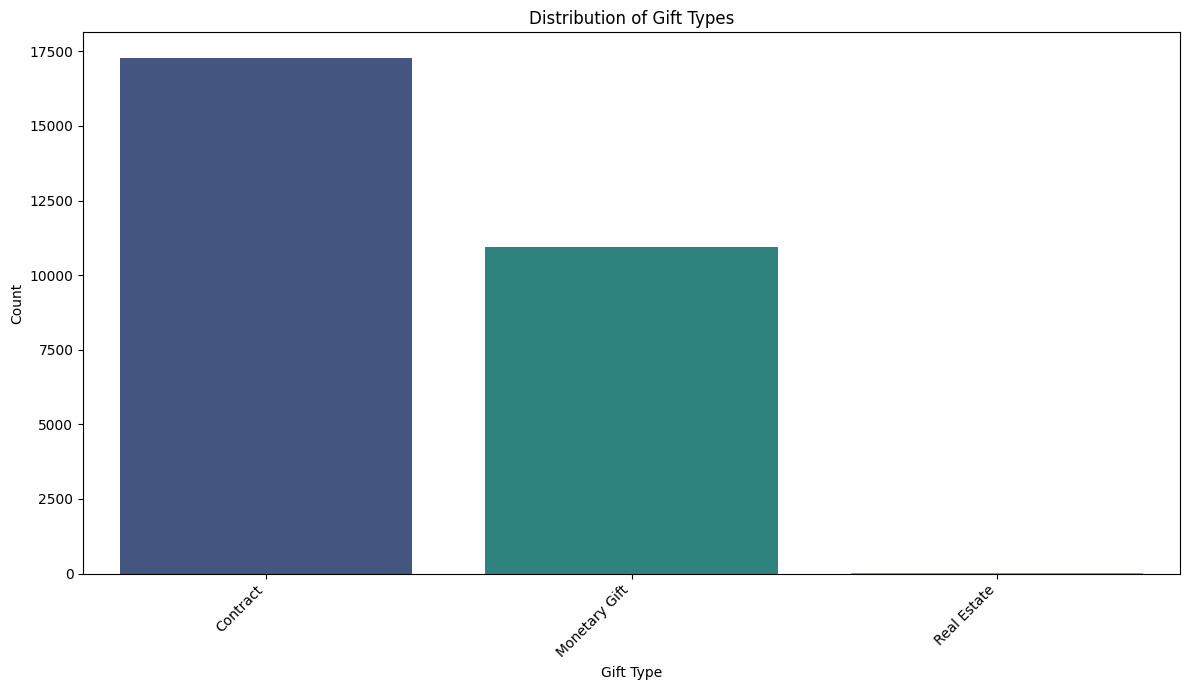

In [13]:
gift_type_counts = df1['Gift Type'].value_counts()
display(gift_type_counts)
plt.figure(figsize=(12, 7))
sns.barplot(x=gift_type_counts.index, y=gift_type_counts.values, palette='viridis')
plt.title('Distribution of Gift Types')
plt.xlabel('Gift Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [14]:
total_gifts = gift_type_counts.sum()
percentages = (gift_type_counts / total_gifts) * 100
display(percentages)

,count
Gift Type,
Contract,61.209737
Monetary Gift,38.751285
Real Estate,0.038978


As you can see, roughly 61 percent of gifts are in the form of contracts, and a little less than 39 percent are just cash. Only a tiny percentage, 0.03 percent, make donations in the form of real estate. I would imagine this is a result of two factors: most foreign entities not having an American real estate portfolio with assets to spare (go figure), but also the hassle that an institution would have to go through to either use the property for their own purposes or sell/lease it for revenue.

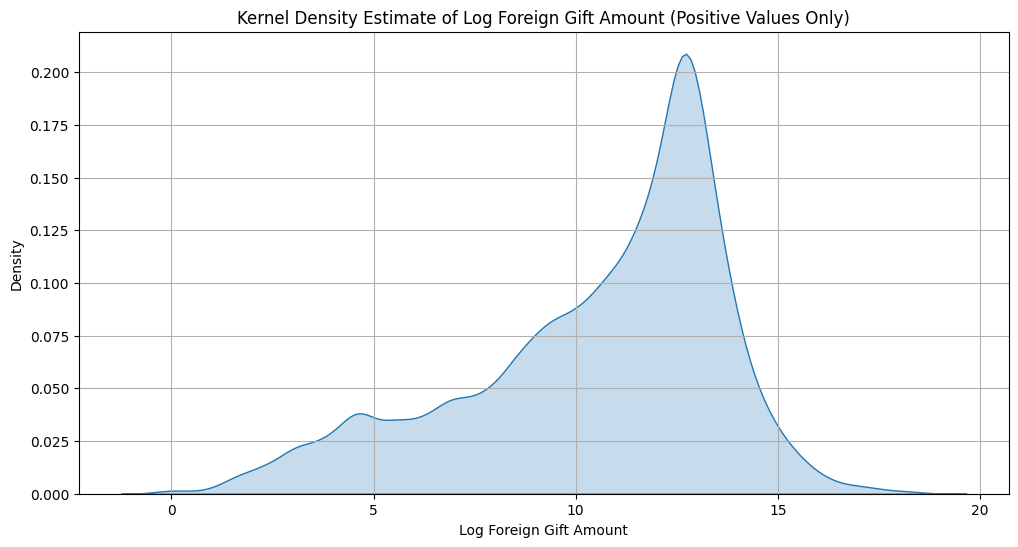

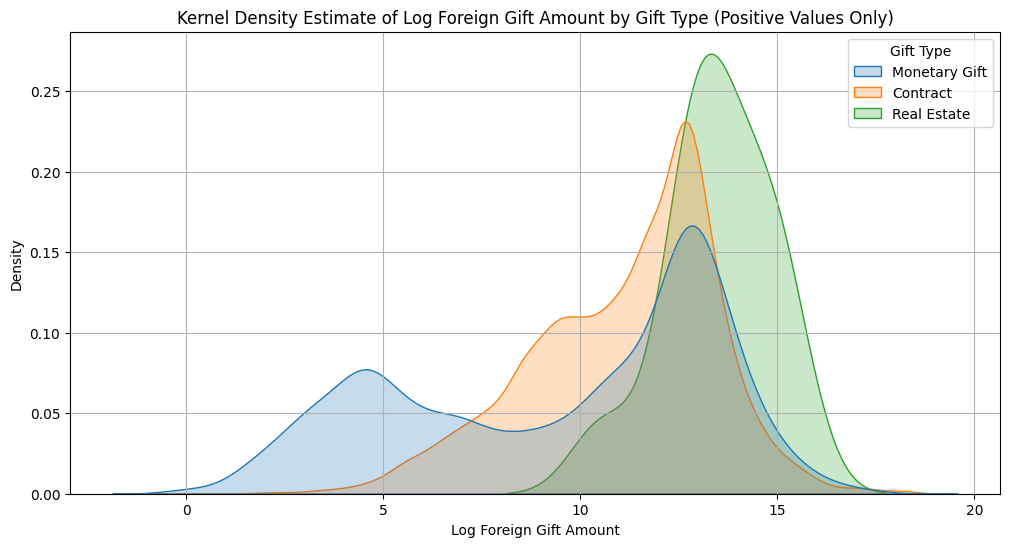

In [16]:
#i decided to exclude the negative values to keep the visual focused on actual gifts rather than whatever the negative numbers were supposed to represent
log_foreign_gift_amount = np.log(df1[df1['Foreign Gift Amount'] > 0]['Foreign Gift Amount'])

plt.figure(figsize=(12, 6))
sns.kdeplot(log_foreign_gift_amount, fill=True)
plt.title('Kernel Density Estimate of Log Foreign Gift Amount (Positive Values Only)')
plt.xlabel('Log Foreign Gift Amount')
plt.ylabel('Density')
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
sns.kdeplot(data=df1[df1['Foreign Gift Amount'] > 0], x=np.log(df1[df1['Foreign Gift Amount'] > 0]['Foreign Gift Amount']), hue='Gift Type', fill=True, common_norm=False)
plt.title('Kernel Density Estimate of Log Foreign Gift Amount by Gift Type (Positive Values Only)')
plt.xlabel('Log Foreign Gift Amount')
plt.ylabel('Density')
plt.grid(True)
plt.show()

There seem to be many more monetary gifts on the lower end of things, which makes sense given that such gifts can be made by any entity of any size. On the other hand, real estate gifts represent many of the most valuable gifts. This also makes perfect sense given that (A) real estate assets are naturally valuable, and (B) universities would probably only accept exceptionally valuable real estate gifts, rather than some run-down piece of land that isn't worth anything.

In [17]:
print('Top 15 Countries by Number of Gifts:')
top_15_by_count = df1['Country of Giftor'].value_counts().head(15)
display(top_15_by_count)

print('\nTop 15 Countries by Amount Given:')
top_15_by_amount = df1.groupby('Country of Giftor')['Foreign Gift Amount'].sum().nlargest(15)
display(top_15_by_amount)

Top 15 Countries by Number of Gifts:


,count
Country of Giftor,
ENGLAND,3655
CHINA,2461
CANADA,2344
JAPAN,1896
SWITZERLAND,1676
SAUDI ARABIA,1610
FRANCE,1437
GERMANY,1394
HONG KONG,1080



Top 15 Countries by Amount Given:


,Foreign Gift Amount
Country of Giftor,
QATAR,2706240869
ENGLAND,1464906771
CHINA,1237952112
SAUDI ARABIA,1065205930
BERMUDA,899593972
CANADA,898160656
HONG KONG,887402529
JAPAN,655954776
SWITZERLAND,619899445


In [18]:
print('Top Giftors by Amount Given:')
top_giftors_by_amount = df1.groupby('Giftor Name')['Foreign Gift Amount'].sum().nlargest(15)
display(top_giftors_by_amount)

Top Giftors by Amount Given:


,Foreign Gift Amount
Giftor Name,
Qatar Foundation,1166503744
Qatar Foundation/Qatar National Res,796197000
Qatar Foundation for Education,373945215
Anonymous,338793629
Saudi Arabian Cultural Mission,275221475
HCL,190000000
Church of Jesus Christ of LDS,185203715
Emirates Institute for Advanced Sc,170641244
QIC,148355497


I actually read about this not too long ago! (I think in The Economist?) Almost all of this Qatari money you see is downhill of the Qatar's sovereign wealth fund. Thanks to a massive government surplus, these guys were able to funnel copious amounts of money into carefully (maybe sometimes also not so carefully) selected capital investments and philanthropy. This acheives two goals: it ensures the long-term economic future of Qatar's very energy-dependent economy for when the oil and LNG dries up, and buys international goodwill and sympathy. The latter was especially important not too long ago, where Qatar's very existence was threatened by its much bigger, stronger neighbor, Saudi Arabia.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]